**House Prices: Predição de Preços de Residências Utilizando Machine Learning**

**Introdução**

O dataset House Prices contém informações sobre aproximadamente 1.460 residências na cidade de Ames, Iowa, sendo descritas por cerca de 80 variáveis relacionadas às características dos imóveis. Neste projeto, os dados serão analisados, limpos e preparados com o objetivo de treinar modelos de Machine Learning capazes de prever o preço de venda de imóveis com base em suas características.

**Objetivos do projeto**

Responder as seguintes perguntas:

**Sobre os imóveis:**
1. Casas com maior área interna custam mais?
2. A qualidade da construção influência muito o preço?
3. Casas mais novas custam mais que casas antigas?
4. Casas que foram recentemente reformadas possuem maior valor de mercado?
5. Imóveis com mais banheiros possuem mais valor agregado?
6. A localização é um dos fatores que mais influenciam o preço dos imóveis?

**Sobre Machine Learning:**


7. Quais características mais influenciam o preço de uma casa?
8. Qual algoritmo supervisionado é o melhor na previsão dos preços?
9. Existe diferença no resultado da regressão linear quando todas as variáveis são usadas?
10. A engenharia de features foi útil nesse projeto? Qual seu efeito?
11. É possível identificar diferentes perfis de residências usando apenas suas características, sem usar o preço de venda?



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

1º Coletando os dados.

In [ ]:
teste = pd.read_csv('test.csv')
treino = pd.read_csv('train.csv')

2º Primeiras análises:


In [ ]:
# Analisando número de colunas e linhas
treino.shape
# Assim, há 1460 linhas e 81 colunas.

(1460, 81)

In [ ]:
# Analisando primeiras linhas
treino.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
treino.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [ ]:
print(f"Média dos preços: {treino['SalePrice'].mean():.2f}")
print(f"Mediana dos preços: {treino['SalePrice'].median():.2f}")
print(f"Moda dos preços: {treino['SalePrice'].mode()[0]:.2f}")

Média dos preços: 180921.20
Mediana dos preços: 163000.00
Moda dos preços: 140000.00


3º Limpeza de dados

**Verificando valores faltantes**

In [ ]:
# Observando a porcentagem de valores faltantes:
faltantes = pd.DataFrame({ # criação de dataframe
    'Ausentes': treino.isnull().sum(), # soma de valores faltantes
    'Percentual (%)': round(treino.isnull().mean() * 100, 2) # percentual para valores faltantes.
})

faltantes = faltantes[faltantes['Ausentes'] > 0]
faltantes.sort_values('Percentual (%)', ascending=False)

,Ausentes,Percentual (%)
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


É possível observar que algumas colunas apresentam uma quantidade muito alta de valores ausentes. Para definir a melhor estratégia de tratamento, é necessário investigar o significado de cada variável por meio do arquivo data_description, conjunto de dados descritivo, que mostra o significado de cada variável.

A partir dessa análise, foi identificado que diversas colunas, como PoolQC, Alley, Fence e FireplaceQu, representam características que algumas casas não vão possuir. Nesses casos, os valores ausentes não são erros nem falhas na coleta dos dados, sendo, assim, correspondentes à inexistência dessas características no imóvel. Portanto, uma estratégia adequada é substituir os valores ausentes por uma categoria como "None", indicando a ausência do recurso para o modelo.

Para variáveis numéricas que indicam a existência dessas características, como as variáveis GarageYrBlt e MasVnrArea, os valores ausentes foram substituídos por 0, indicando que o imóvel não possui garagem ou revestimento de alvenaria e, por causa disso, não existe um ano de construção ou área correspondente.

A variável Electrical, apresentou poucos valores ausentes e representa uma característica categórica obrigatória dos imóveis, assim, não faz sentido usar média, nem mediana. Utilizei a moda, preenchendo os valores faltantes com a categoria mais frequente no conjunto de dados.

Já para a variável LotFrontage, foi utilizada a mediana, pois ela é uma variável numérica contínua e apresenta distribuição assimétrica. Diferentemente da média, a mediana é menos influenciada por valores extremos, assim, ajuda a preservar melhor a distribuição original dos dados.


In [ ]:
def tratamento_nulos(df):

    df = df.fillna({
        'PoolQC': 'None',
        'MiscFeature': 'None',
        'Alley': 'None',
        'Fence': 'None',
        'FireplaceQu': 'None',
        'GarageType': 'None',
        'GarageFinish': 'None',
        'GarageQual': 'None',
        'GarageCond': 'None',
        'BsmtExposure': 'None',
        'BsmtFinType2': 'None',
        'BsmtQual': 'None',
        'BsmtFinType1': 'None',
        'BsmtCond': 'None'
    })

    df['GarageYrBlt'] = df['GarageYrBlt'].fillna(0)

    if 'Electrical' in df.columns:
        df['Electrical'] = df['Electrical'].fillna(
            df['Electrical'].mode()[0]
        )

    df['MasVnrType'] = df['MasVnrType'].fillna('None')
    df['MasVnrArea'] = df['MasVnrArea'].fillna(0)
    df['LotFrontage'] = df['LotFrontage'].fillna(
        df['LotFrontage'].median()
    )

    return df

In [ ]:
#testando a função tratamento_nulos()
treino = tratamento_nulos(treino)
teste = tratamento_nulos(teste)

**Investigando outliers**

Antes de decidir remover valores que são outliers, realizei uma investigação para verificar se esses registros apresentavam erros de coleta ou se realmente eram imóveis legítimos.

In [ ]:
q1 = treino['SalePrice'].quantile(0.25)
q3 = treino['SalePrice'].quantile(0.75)
iqr = q3 - q1
lim_inf = q1 - 1.5 * iqr
lim_sup = q3 + 1.5 * iqr
outliers = treino[(treino['SalePrice'] < lim_inf) | (treino['SalePrice'] > lim_sup)] # outliers no preço de venda

# É importante voltar ao arquivo data.descriptions e procurar variáveis interessantes para procurar nos outliers:
# OverallQual: avalia o material e o acabamento da casa.
# OverallCond: avalia a condição da casa.
# LotArea: área disponível.
# GrLivArea: área habitável acima do solo.
# outliers em ordem decrescente considerando as variáveis acima:

outliers[[
    'SalePrice',
    'OverallQual',
    'OverallCond',
    'LotArea',
    'GrLivArea']
].sort_values(
    by = 'SalePrice',
    ascending=False
)

# Foi realizada uma investigação dos outliers identificados na variável
# SalePrice por meio das variáveis OverallQual, OverallCond, LotArea e
# GrLivArea.
# Observou-se que os imóveis com maiores preços apresentam características
# compatíveis com seus valores de venda, como melhor qualidade da construção,
# maior área do terreno e maior área habitável.
# Dessa forma, concluiu-se que esses outliers representam observações
# legítimas do conjunto de dados e não erros de registro. Portanto,
# optei por mantê-los, pois sua remoção poderia eliminar informações
# importantes para o treinamento dos modelos de Machine Learning.

,SalePrice,OverallQual,OverallCond,LotArea,GrLivArea
691,755000,10,6,21535,4316
1182,745000,10,5,15623,4476
1169,625000,10,5,35760,3627
898,611657,9,5,12919,2364
803,582933,9,5,13891,2822
...,...,...,...,...,...
990,348000,8,5,9452,2392
642,345000,8,7,13860,2704
11,345000,9,5,11924,2324
320,342643,9,5,16259,2596


**Verificando duplicatas**

Realizei uma verificação de duplicatas para garantir que cada linha do dataset representasse realmente um único imóvel. A existência desses registros poderia fazer com que o modelo atribuisse maior peso a determinados imóveis durante o treinamento. Como não foram encontradas duplicatas, nenhuma linha precisou ser removida.

In [ ]:
def verificar_duplicatas(df):

    duplicatas = df.duplicated().sum()

    print('Duplicatas encontradas:' ,duplicatas)

    return duplicatas

In [ ]:
# testando a função verificar_duplicatas():
verificar_duplicatas(treino)
verificar_duplicatas(teste)
# Não foram encontradas duplicatas nesse dataset. Assim, não vai ser necessário
# fazer nenhum tratamento de dados em relação à isso.

Duplicatas encontradas: 0
Duplicatas encontradas: 0


np.int64(0)

4º Análise exploratória de dados

In [ ]:
# Tipos de variáveis encontradas no dataset
treino.info()
# Os tipos de variáveis no dataset são:
# int: números inteiros sem casas decimais.
# float: números inteiros com casas decimais.
# object: dados categóricos ou strings.
# Int e float são dados numéricos, enquanto
# que object são dados categóricos, que nas
# próximas etapas vão ser transformados em
# numericos.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          1460 non-null   object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [ ]:
print(f"O mínimo de preço é: {treino['SalePrice'].min()}")
print(f"O maximo de preço é: {treino['SalePrice'].max()}")
print(f"O desvio padrão é: {treino['SalePrice'].std():.2f}") # Quanto que os valores se afastam da média
q1 = treino['SalePrice'].quantile(0.25)
q3 = treino['SalePrice'].quantile(0.75)
print("1º quartil: ",q1)
print("2º quartil: ",treino['SalePrice'].median())
print("3º quartil: ",q3)
# O primeiro quartil (Q1 = 129.975) indica que 25% dos imóveis
# possuem preço inferior ou igual a aproximadamente 130 mil.
# O segundo quartil (Q2 = 163.000) indica que 50% dos imóveis possuem
# preço inferior ou igual a 163 mil.
# O terceiro quartil (Q3 = 214.000) indica que 75% dos imóveis
# possuem preço inferior ou igual a 214 mil.
# Conclui-se que os preços nesse dataset apresentam valores mínimos
# e máximos muitos distantes entre si e também grande dispersão entre
# os valores, evidenciado pelo grande desvio padrão de 79 mil.

O mínimo de preço é: 34900
O maximo de preço é: 755000
O desvio padrão é: 79442.50
1º quartil:  129975.0
2º quartil:  163000.0
3º quartil:  214000.0


Text(0, 0.5, 'Frequência')

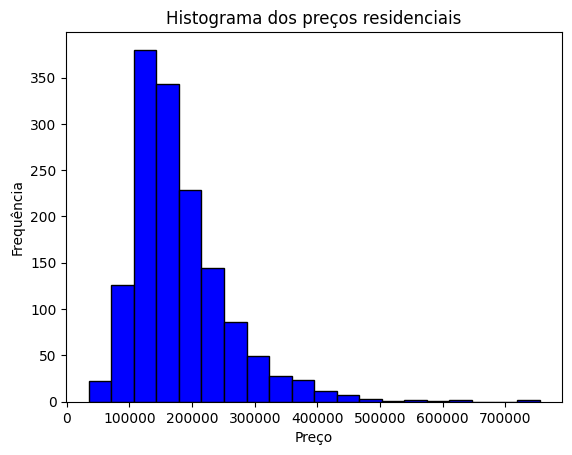

In [ ]:
# Histograma para entender a distribuição dos preços
plt.hist(treino['SalePrice'], bins=20, color= 'blue', edgecolor='black')
plt.title("Histograma dos preços residenciais")
plt.xlabel("Preço")
plt.ylabel("Frequência")
# Nesse histograma é possível ver que há uma assimetria a direita, pois a média é maior que
# a mediana e esta é maior que a moda.
# A maioria das casas possui valor entre 100 mil e 250 mil.
# Há alguns outliers entre as casas, com casas alcançando 750 mil.

Text(0.5, 1.0, 'Boxplot dos preços residenciais')

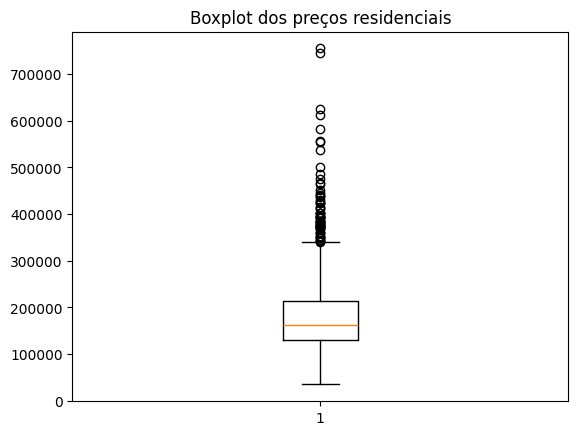

In [ ]:
# Boxplot para observar outliers no dataset.
plt.boxplot(treino['SalePrice'])
plt.title("Boxplot dos preços residenciais")
# É possível observar que há muitos outliers acima de aproximadamente
# 350 mil.

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64


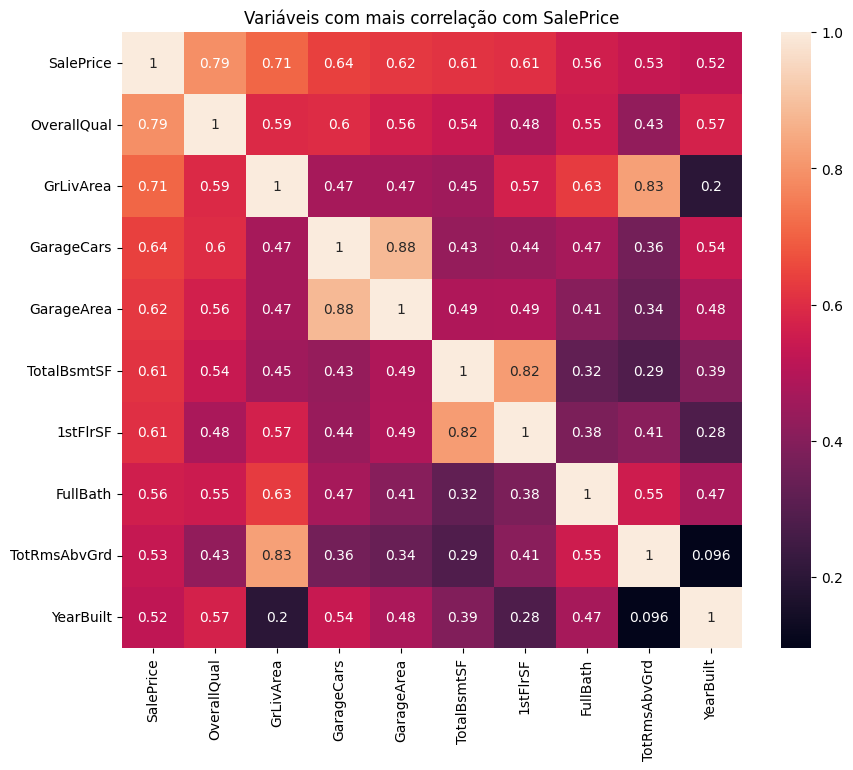

In [ ]:
# Visualizando correlações com o heatmap:
# O objetivo do heatmap foi identificar quais variáveis apresentam maior correlação
# com o preço das casas. Essa análise auxiliou na interpretação dos dados
# e na seleção de variáveis de interesse utilizadas pelos modelos.
correlacao = treino.corr(numeric_only=True) # matriz de correlação com todas as variáveis numéricas.

top_correlacoes = correlacao['SalePrice'].sort_values( # pegando a matriz de correlações
# que já existe do preço e ordenando.
    ascending=False
).head(10)

print(top_correlacoes)
maiores_correlacoes = top_correlacoes.index
plt.figure(figsize=(10, 8))
sns.heatmap(treino[maiores_correlacoes].corr(), annot=True) # como as 12 maiores variáveis se relacionam entre si.
plt.title("Variáveis com mais correlação com SalePrice")
plt.show()

# É possível observar que as variáveis mais correlacionadas com o 'SalePrice' são:
# OverallQual (Qualidade da casa), GrLivArea (área habitavel acima do nivel do solo),
# GarageCars (quantas automóveis cabem na garagem), GarageArea (área da garagem),
# TotalBsmtSF (quantidade de banheiros), 1stFlrSF, FullBath,  TotRmsAbvGrd e YearBuilt.
# Algumas dessas variáveis são muitos relacionadas entre si e vão ser usadas na etapa
# de engenharia de features pra criar uma nova variável mais correlacionada.

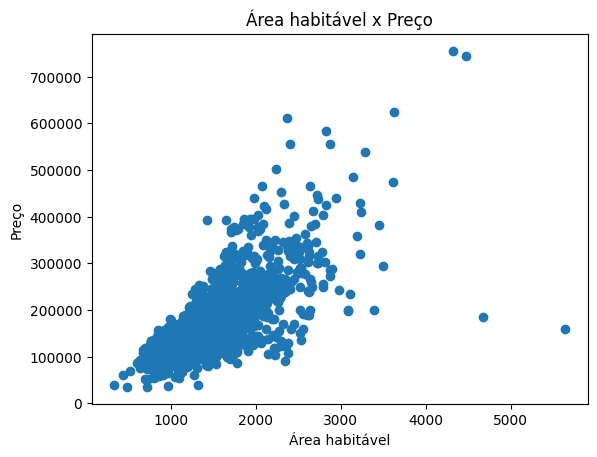

In [ ]:
# Relação entre área habitável do imóvel e o preço
plt.scatter(
    treino['GrLivArea'],
    treino['SalePrice']
)

plt.xlabel('Área habitável')
plt.ylabel('Preço')
plt.title('Área habitável x Preço')
plt.show()
# Observa-se uma relação positiva entre a área habitável e o preço dos
# imóveis. Em geral, casas maiores tendem a possuir preços mais elevados.
# Entretanto, a dispersão dos pontos indica que outras variáveis também
# influenciam o valor de venda dos imóveis.

Os 10 bairros mais caros são:
Neighborhood
NoRidge    335295.317073
NridgHt    316270.623377
StoneBr    310499.000000
Timber     242247.447368
Veenker    238772.727273
Somerst    225379.837209
ClearCr    212565.428571
Crawfor    210624.725490
CollgCr    197965.773333
Blmngtn    194870.882353
Name: SalePrice, dtype: float64

Os 10 bairros mais baratos são:
Neighborhood
NPkVill    142694.444444
SWISU      142591.360000
Blueste    137500.000000
Sawyer     136793.135135
OldTown    128225.300885
Edwards    128219.700000
BrkSide    124834.051724
BrDale     104493.750000
IDOTRR     100123.783784
MeadowV     98576.470588
Name: SalePrice, dtype: float64


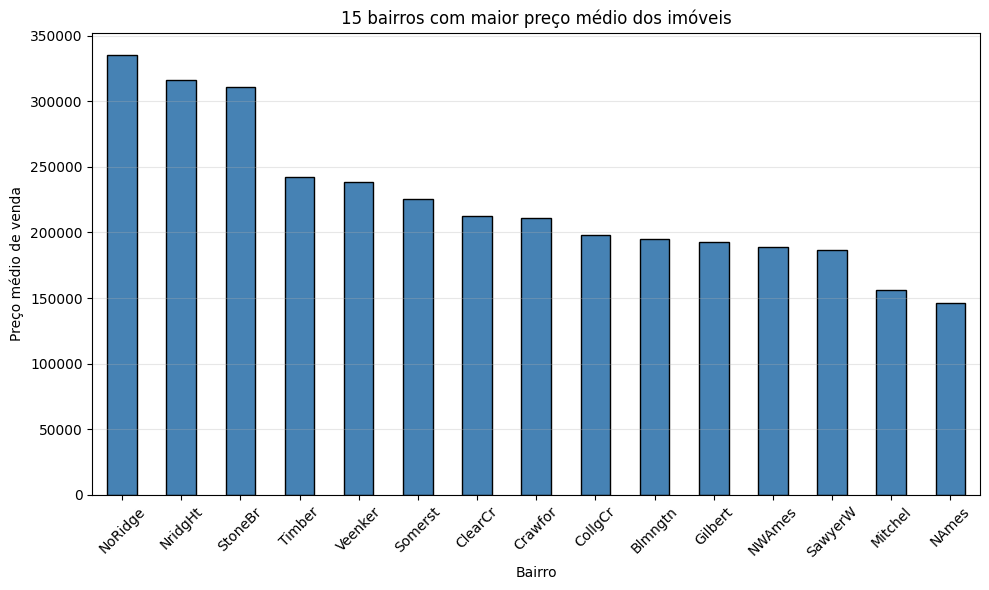

In [ ]:
# Calculando o preço médio dos imóveis por bairro
vizinhanca_preco = (
    treino.groupby("Neighborhood")["SalePrice"]
    .mean()
    .sort_values(ascending=False)
)

# Exibindo os 10 bairros com maior e menor preço médio
print("Os 10 bairros mais caros são:")
print(vizinhanca_preco.head(10))

print("\nOs 10 bairros mais baratos são:")
print(vizinhanca_preco.tail(10))

# Gráfico dos 15 bairros com maior preço médio
plt.figure(figsize=(10,6))

vizinhanca_preco.head(15).plot(
    kind="bar",
    color="steelblue",
    edgecolor="black"
)

plt.title("15 bairros com maior preço médio dos imóveis")
plt.xlabel("Bairro")
plt.ylabel("Preço médio de venda")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# é possível observar que o bairro da residência influencia
# bastante o preço do imóvel. Essa diferença é muito presente
# quando compara o bairro mais caro ('NoRidge') com o mais barato
# ('Meadow'), em que o mais caro custa quase 4x mais que o outro.

5º Preparação para o treinamento dos modelos

Os modelos de machine learning tem dificuldade com variáveis categóricas, ou seja aquelas que não são numéricas. Assim, precisamos fazer com que essas variáveis se tornem numéricas.
Isso acontece de duas formas: Label Enconding e One-Hot Enconding.
*   Label Enconding: transformação da coluna em um valor numérico único. Usado quando as variáveis categóricas são ordinais.
*   One-Hot Enconding: converte cada categoria em uma nova variável binária, que é a variável dummy. Há a criação de colunas adicionais. Eficaz para variáveis categóricas nominais e quando o número de colunas é pequeno.



In [ ]:
# Descobrindo quantas variáveis categóricas temos no dataset
categoricas = treino.select_dtypes(include='object').columns
print(len(categoricas))
# Como temos 43 variáveis categóricas, vou filtrar elas em ordinais e nominais
# para aplicar one-hot ou label encoding.
treino.info()

43
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          1460 non-null   object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  Overa

In [ ]:
# voltando ao arquivo data.descriptions:
# VARIÁVEIS ORDINAIS:
# LotShape, Utilities, LandSlope,
# ExterQual, ExterCond, BsmtQual,
# BsmtCond, BsmtExposure, BsmtFinType1,
# BsmtFinType2, HeatingQC, Electrical,
# KitchenQual, Functional, FireplaceQu,
# GarageFinish, GarageQual, GarageCond,
# PavedDrive, PoolQC, Fence, OverallQual,
# OverallCond
# VARIÁVEIS NOMINAIS
# MSZoning, Street, Alley,
# LandContour, LotConfig, Neighborhood,
# Condition1, Condition2, BldgType,
# HouseStyle, RoofStyle, RoofMatl,
# Exterior1st, Exterior2nd, MasVnrType,
# Foundation, Heating, CentralAir,
# GarageType, MiscFeature, SaleType,
# SaleCondition

In [ ]:
# Algumas variáveis possuem ordem natural e serão convertidas
# para valores numéricos (Ordinal Encoding). As variáveis
# nominais serão transformadas posteriormente utilizando
# One-Hot Encoding.
# Variáveis escolhidas:
# ExterQual, ExterCond, KitchenQual
# BsmtQual, GarageQual, GarageCond
# HeatingQC

def tratamento_ordinais(df):

    ordem = {
        'None': 0,
        'Po': 1,
        'Fa': 2,
        'TA': 3,
        'Gd': 4,
        'Ex': 5
    }

    colunas_ordem = [
        'ExterQual',
        'ExterCond',
        'KitchenQual',
        'BsmtQual',
        'GarageQual',
        'GarageCond',
        'HeatingQC'
    ]

    for coluna in colunas_ordem:
        df[coluna] = df[coluna].map(ordem)

    return df

In [ ]:
#testando tratamento_ordinais()
treino = tratamento_ordinais(treino)
teste = tratamento_ordinais(teste)

One-hot enconding: As variáveis categóricas não podem ser usadas diretamente pelos algoritmos de Machine Learning, pois eles trabalham com valores numéricos. Por isso, apliquei o One-Hot Encoding, que transforma cada categoria em uma coluna binária (0 ou 1), permitindo que essas informações sejam utilizadas sem criar uma relação de ordem entre as categorias.

In [ ]:
def one_hot(df, categoricas):

    df = pd.get_dummies(
        df,
        columns=categoricas,
        drop_first=True
    )

    return df

In [ ]:
# Testando one_hot()
treino = one_hot(treino, categoricas)
teste = one_hot(teste, categoricas)

In [ ]:
# Alinhamento de colunas
# garantindo que as duas tenham exatamente as mesmas colunas
# se uma só existir no treino, ela passa a existir no teste.
def alinhar_colunas(treino, teste):

    treino, teste = treino.align(
        teste,
        join='left',
        axis=1,
        fill_value=0
    )

    return treino, teste

In [ ]:
# testando alinhar_colunas()
treino, teste = alinhar_colunas(treino, teste)

In [ ]:
# Verificando se ainda há variáveis categóricas
def encontrar_categoricas(df):

    return df.select_dtypes(
        include='object'
    ).columns

In [ ]:
# testando a função encontrar_categoricas
categoricas_treino = encontrar_categoricas(treino)
categoricas_teste = encontrar_categoricas(teste)
print("Categóricas do treino: ", len(categoricas_treino))
print("Categóricas do teste: ", len(categoricas_teste))


Categóricas do treino:  0
Categóricas do teste:  0


6º Engenharia de Features

Nesta etapa criei novas variáveis com a união das existentes, com o objetivo da de criar variáveis mais representativas a partir das informações originais do dataset. Essa etapa facilita o aprendizado dos modelos, reunindo informações relacionadas em novos atributos que são mais úteis para o modelo.

Também removi a coluna Id, pois ela não é tão útil para nossa análise e para o treinamento do modelo, já que serve apenas para a identificação das residências.

In [ ]:
def ajustes_finais(df):
    df["IdadeCasa"] = df['YrSold'] - df['YearBuilt'] # Ano de venda - Ano de construção.
    # Criei essa variável para verificar se a idade da casa influencia nos preços.
    # Casas mais novas são mais caras?

    df["AreaInterna"] = (df['1stFlrSF'] +
    df['2ndFlrSF'] +
    df['TotalBsmtSF']) # Soma das áreas dos andares + porão.
    # Optei por criar essa variável para saber a influência
    # da área interna total da casa em relação aos preços.
    # Casas maiores são mais caras? ou tem outras variáveis melhores?

    df['AreaExterna'] = (df["WoodDeckSF"] + # Soma das áreas externas
    df["OpenPorchSF"] +
    df["EnclosedPorch"] +
    df["3SsnPorch"] +
    df["ScreenPorch"])
    # A área externa da casa influencia nos preços?

    df["IdadeReforma"] = df["YrSold"] - df["YearRemodAdd"] # Tempo desde a última reforma.
    # Optei por criar essa para verificar se casas recentemente reformadas são mais caras.

    df["TotalBanheiros"] = (
    df["FullBath"] +
    0.5 * df["HalfBath"] +
    df["BsmtFullBath"] +
    0.5 * df["BsmtHalfBath"]
    )
    # Casas com mais banheiros são mais caras?

    df = df.drop('Id', axis=1) # exclusão de coluna Id, que não vai ser relevante para a análise.

    return df

In [ ]:
ajustes_finais(treino)
ajustes_finais(teste)

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,IdadeCasa,AreaInterna,AreaExterna,IdadeReforma,TotalBanheiros
0,20,80.0,11622,5,6,1961,1961,0.0,468.0,144.0,...,False,False,False,True,False,49,1778.0,260,49,1.0
1,20,81.0,14267,6,6,1958,1958,108.0,923.0,0.0,...,False,False,False,True,False,52,2658.0,429,52,1.5
2,60,74.0,13830,5,5,1997,1998,0.0,791.0,0.0,...,False,False,False,True,False,13,2557.0,246,12,2.5
3,60,78.0,9978,6,6,1998,1998,20.0,602.0,0.0,...,False,False,False,True,False,12,2530.0,396,12,2.5
4,120,43.0,5005,8,5,1992,1992,0.0,263.0,0.0,...,False,False,False,True,False,18,2560.0,226,18,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,160,21.0,1936,4,7,1970,1970,0.0,0.0,0.0,...,False,False,False,True,False,36,1638.0,0,36,1.5
1455,160,21.0,1894,4,5,1970,1970,0.0,252.0,0.0,...,False,False,False,False,False,36,1638.0,24,36,1.5
1456,20,160.0,20000,5,7,1960,1996,0.0,1224.0,0.0,...,False,False,False,False,False,46,2448.0,474,10,2.0
1457,85,62.0,10441,5,5,1992,1992,0.0,337.0,0.0,...,False,False,False,True,False,14,1882.0,112,14,1.5


**Verificando as variáveis mais correlacionadas**


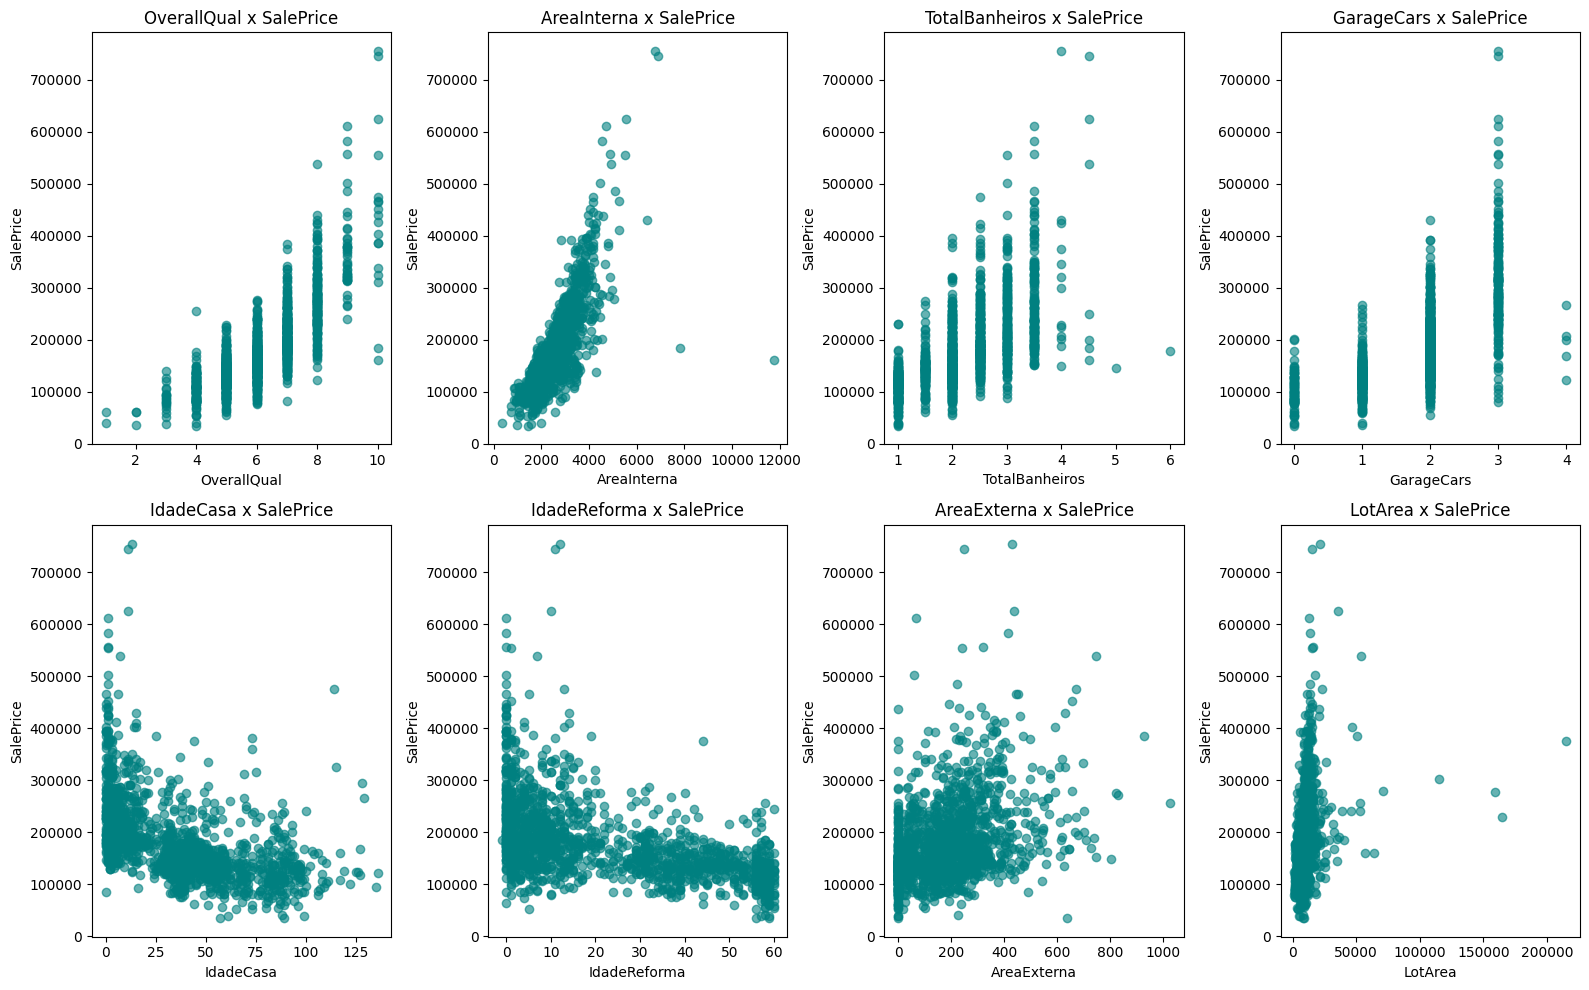

In [ ]:
# Entendendo melhor a relação entre variáveis e o SalePrice, e seus comportamentos.
import matplotlib.pyplot as plt

# Variáveis escolhidas
variaveis = [
    "OverallQual",
    "AreaInterna",
    "TotalBanheiros",
    "GarageCars",
    "IdadeCasa",
    "IdadeReforma",
    "AreaExterna",
    'LotArea'
]
fig, axes = plt.subplots(2, 4, figsize=(16,10))
axes = axes.flatten()

for i, coluna in enumerate(variaveis):
    axes[i].scatter(
        treino[coluna],
        treino["SalePrice"],
        alpha=0.6,
        color="teal"
    )

    axes[i].set_title(f"{coluna} x SalePrice")
    axes[i].set_xlabel(coluna)
    axes[i].set_ylabel("SalePrice")

plt.tight_layout()
plt.show()

Os gráficos mostram que algumas variáveis apresentam uma relação bem direta com o preço das casas. As variáveis OverallQual e AreaInterna possuem a relação entre o preço mais forte, indicando que imóveis com maior qualidade de construção e maior área interna vão tender a possuir maior valor.

A variável TotalBanheiros também apresenta uma relação positiva, mostrando que casas com maior número de banheiros costumam ser mais caros, porém existe maior dispersão para imóveis com quatro ou mais banheiros. De maneira parecida, a variável GarageCars indica que residências que cabem mais veículos têm tendência a custarem mais, principalmente aquelas com garagem para até três carros.

Já IdadeCasa e IdadeReforma apresentam uma relação invertida. Isto é, em geral casas mais novas ou reformadas recentemente possuem preços maiores, enquanto imóveis mais antigos tendem a custarem menos. Porém, existem exceções, indicando que outros fatores, como qualidade da construção e área interna, também exercem influência significativa no preço final.

Por fim, A relação entre AreaExterna e SalePrice é fraca quando comparada às demais variáveis. Há imóveis com maior área externa que apresentem preços altos, porém, observa-se uma grande dispersão dos pontos, o que indica que casas com áreas externas semelhantes podem possuir valores de venda bastante diferentes. A variável LotArea mostra uma relação positiva bem fraca, em que a grande maioria dos móveis está em terrenos menores, e poucos em terrenos maiores, além de que terrenos com o mesmo tamanho apresentam valores bem diferentes entre si.

Assim, os gráficos provam que existe uma relação entre essas variáveis e o preço das casas, o que justifica o seu uso no treinamento dos modelos de ML.

7º Treinamento dos modelos

Para essa etapa, escolhi os modelos Regressão Linear, Decision Tree Regressor e Random Forest. A Regressão Linear foi uusada como modelo de referência, por ser simples e muito usada em problemas de regressão. Já a Decision Tree foi escolhida por sua capacidade de mostrar relações não lineares entre as variáveis, enquanto a Random Forest foi utilizada por combinar diversas Árvores de Decisão, diminuindo o risco de overfitting e, geralmente, apresentando melhor desempenho em problemas de regressão.

Além disso, realizei dois experimentos com a Regressão Linear para avaliar se a seleção de variáveis e a engenharia de features influenciariam o desempenho do modelo.

Para comparar os modelos, utilizei o método Hold-out (train/test), no qual os dados foram divididos em 80% para treinamento e 20% para teste. O conjunto de treinamento foi utilizado para que os modelos aprendessem os padrões presentes nos dados, enquanto o conjunto de teste permitiu avaliar a capacidade de generalização dos modelos em dados novos.

Por fim, o desempenho foi avaliado por meio das métricas MAE (Erro Absoluto Médio), que representa o erro médio das previsões, RMSE (Raiz do Erro Quadrático Médio), que penaliza previsões com erros maiores e R² (Coeficiente de Determinação), que indica a proporção da variação dos preços das casas que o modelo consegue explicar.

Experimento 1: **Regressão Linear usando todas as variáveis**

        Id  MSSubClass  LotFrontage  LotArea  OverallQual  OverallCond  \
892    893          20         70.0     8414            6            8   
1105  1106          60         98.0    12256            8            5   
413    414          30         56.0     8960            5            6   
522    523          50         50.0     5000            6            7   
1036  1037          20         89.0    12898            9            5   
...    ...         ...          ...      ...          ...          ...   
479    480          30         50.0     5925            4            7   
1361  1362          20        124.0    16158            7            5   
802    803          60         63.0     8199            7            5   
651    652          70         60.0     9084            4            5   
722    723          20         70.0     8120            4            7   

      YearBuilt  YearRemodAdd  MasVnrArea  BsmtFinSF1  ...  \
892        1963          2003         0.0        

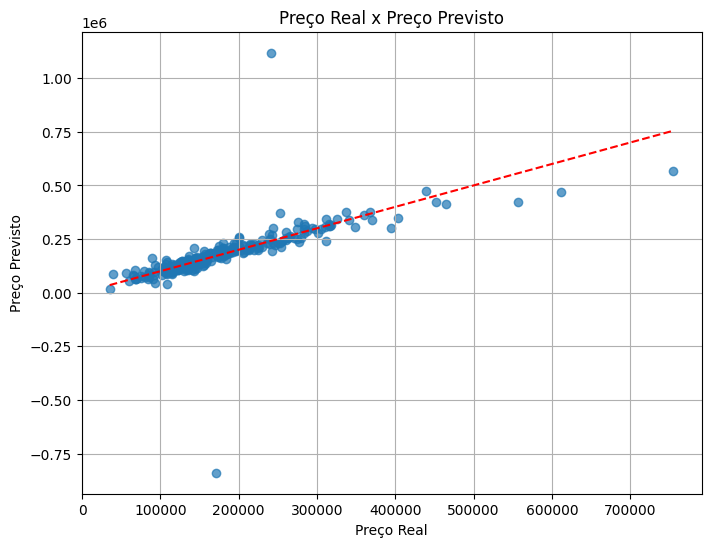

In [ ]:
# Fiz essa testagem pra ver como a regressão se comporta
# com todas as variáveis em comparação com a regressão
# selecionando as variáveis mais relacionadas.
# Escolhida por ser um algoritmo supervisionado utilizado para prever valores numéricos.
# Neste projeto, como o objetivo é prever o preço das casas (SalePrice) utilizando as
# variáveis mais relevantes do conjunto de dados a regressão foi útil.

import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Como neste experimento a ideia é usar todas as variáveis
# disponíveis, a variável 'SalePrice' é 'ignorada'' e todas as
# demais colunas são utilizadas como variáveis no X.
X = treino.drop(columns=['SalePrice'])
y = treino["SalePrice"]


# Separação dos dados em treino e teste.
# Utilizei 80% dos dados para que o modelo aprenda os padrões e
# coloquei 20% para avaliar seu desempenho em casas novas.
def separacao_dados(X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )
    return X_train, X_test, y_train, y_test


# Criação do modelo de Regressão Linear.
regressao = LinearRegression()


# Etapa de treinamento.
# O modelo analisa os casos do conjunto de treino para aprender
# a relação existente entre as variáveis do imóvel(X) e seu preço(y).
def treinamento(modelo, X_train, y_train):
    modelo.fit(X_train, y_train)
    return modelo


# Depois do treinamento, o modelo realiza previsões para os imóveis
# do conjunto de teste, permitindo comparar os valores previstos com
# os preços reais.
def previsoes(modelo, X_test):
    y_pred = modelo.predict(X_test)
    return y_pred


# Criação de uma tabela com o preço real e o preço previsto.
# Assim, facilita a identificação dos casos em que o
# modelo acertou ou errou
def comparando_resultados(X_test, y_test, y_pred):
    resultado = X_test.copy()
    resultado["Preço Real"] = y_test.values
    resultado["Preço Previsto"] = y_pred
    return resultado


# Cálculo das métricas
# MAE: erro médio das previsões.
# MSE: penaliza mais fortemente erros muito grandes.
# RMSE: erro médio na mesma unidade do preço das casas.
# R²: percentual da variação dos preços explicado pelo modelo.
def calculando_metricas(y_test, y_pred):
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f"MAE: {mae:.2f}")
    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²: {r2:.2f}")

    return mae, mse, rmse, r2


# Gráfico comparando os preços reais com os preços previstos.
# Quanto mais próximos os pontos estiverem da linha vermelha,
# maior a precisão do modelo. Pontos distantes dessa linha
# representam previsões com maior erro.
def grafico_previsoes(y_test, y_pred):
    plt.figure(figsize=(8,6))

    plt.scatter(
        y_test,
        y_pred,
        alpha=0.7
    )

    # Linha de referência que corresponde a uma previsão perfeita.
    plt.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        color="red",
        linestyle="--"
    )

    plt.title("Preço Real x Preço Previsto")
    plt.xlabel("Preço Real")
    plt.ylabel("Preço Previsto")
    plt.grid(True)

    plt.show()


# Chamando as funções:
# Criando o modelo
regressao = LinearRegression()

# Separando treino e teste
X_train, X_test, y_train, y_test = separacao_dados(X, y)

# Treinando
regressao = treinamento(regressao, X_train, y_train)

# Fazendo previsões
y_pred_regressao1 = previsoes(regressao, X_test)

# Comparando
resultado = comparando_resultados(
    X_test,
    y_test,
    y_pred_regressao1
)
print(resultado)

# Métricas
mae, mse, rmse, r2 = calculando_metricas(
    y_test,
    y_pred_regressao1
)

# Testando gráfico preço real x preço previsto
grafico_previsoes(y_test, y_pred_regressao1)



Observando o gráfico de Preço Real x Preço Previsto é possível perceber que sem o filtro de variáveis, o modelo acerta a maioria das previsões mas quando erra as previsões faz de uma forma muito elevada, superestimando muito os preços. Essa situação fez com que esse modelo chegasse a um RMSE(Raiz do Erro Quadrático Médio) muito alto, pois essa métrica penaliza erros muito distantes do verdadeiro, além de possuir um R² de 0,10, um valor muito baixo, indicando que conseguiu explicar apenas cerca de 10% da variação dos preços das casas, evidenciando um baixo desempenho.

Experimento 2: **Regressão Linear após engenharia de features**

      OverallQual  AreaInterna  GrLivArea  GarageCars  GarageArea  \
892             6         2127       1068           1         264   
1105            8         4085       2622           2         712   
413             5         2036       1028           2         360   
522             6         2668       1664           2         420   
1036            9         3240       1620           3         912   
...           ...          ...        ...         ...         ...   
479             4         2038       1131           2         672   
1361            7         3060       1530           2         430   
802             7         2184       1456           2         410   
651             4         2265       1510           1         296   
722             4         1728        864           2         463   

      TotalBanheiros  IdadeCasa  IdadeReforma  LotArea  OverallCond  \
892              1.5         43             3     8414            8   
1105             3.5         

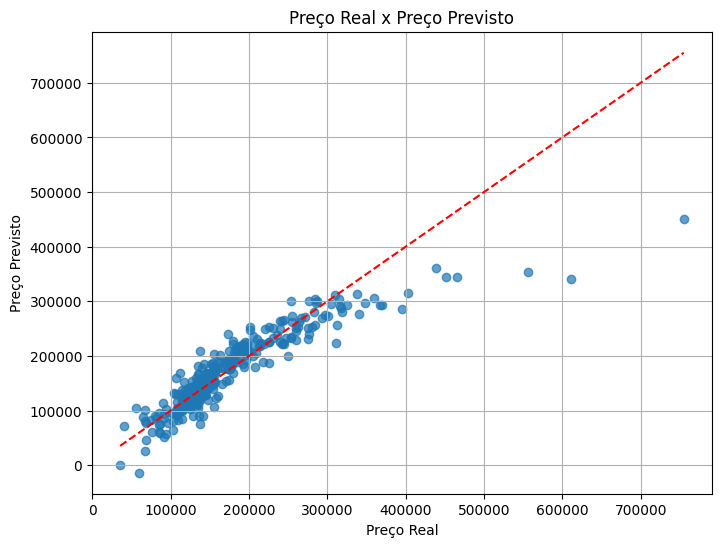

In [ ]:
# Selecionando as variáveis mais correlacionadas com o preço da casa.
# Algumas variáveis foram removidas porque já estavam representadas
# pelas novas features criadas durante a engenharia de atributos.
variaveis = [
    "OverallQual",
    "AreaInterna",
    "GrLivArea",
    "GarageCars",
    "GarageArea",
    "TotalBanheiros",
    "IdadeCasa",
    "IdadeReforma",
    "LotArea",
    "OverallCond"
]
X = treino[variaveis]
y = treino["SalePrice"]


# Chamando as funções:

# Criando o modelo
regressao = LinearRegression()

# Separando treino e teste
X_train, X_test, y_train, y_test = separacao_dados(X, y)

# Treinando
regressao = treinamento(regressao, X_train, y_train)

# Fazendo previsões
y_pred_regressao2 = previsoes(regressao, X_test)

# Comparando
resultado = comparando_resultados(
    X_test,
    y_test,
    y_pred_regressao2
)
print(resultado)

# Métricas
mae, mse, rmse, r2 = calculando_metricas(
    y_test,
    y_pred_regressao2
)

# testando gráfico de preço real x preço previsto
grafico_previsoes(y_test, y_pred_regressao2)

No gráfico de Preço Real x Preço Previsto, é possível observar que a maioria das previsões acertou. Os melhores resultados foram com imóveis com valores próximos de 300 mil, que representam a maioria do conjunto de dados. Já para casas mais caras, o modelo teve maiores erros, isso pode ser motivado porque relação entre as características do imóvel e seu preço torna-se mais complexa e nem sempre pode ser representada por uma relação linear, como é o caso da regressão linear.

Em relação às métricas, o MAE (Erro Absoluto Médio) foi de aproximadamente 23.500, indicando que,em média,o modelo erra esse valor ao prever o preço de um imóvel. Um erro baixo em relação ao preço médio de 180 mil.

O RMSE (Raiz do Erro Quadrático Médio) foi de aproximadamente 38.700. Essa métrica vai penalizar mais os erros maiores,assim, seu valor foi superior ao MAE, indicando que existem alguns imóveis em que a diferença entre o preço real e o previsto é maior, principalmente nas casas mais caras.

Por fim, o R² (Coeficiente de Determinação) teve um valor de 0,80, isso mostra que o modelo conseguiu explicar aproximadamente 80% da variação dos preços das casas utilizando as variáveis selecionadas.

Dessa forma a Regressão Linear apresentou um bom desempenho e pode ser considerada uma boa opção, porém apresentou muitos erros em imóveis com valor superior a 300 mil.

        Id  MSSubClass  LotFrontage  LotArea  OverallQual  OverallCond  \
892    893          20         70.0     8414            6            8   
1105  1106          60         98.0    12256            8            5   
413    414          30         56.0     8960            5            6   
522    523          50         50.0     5000            6            7   
1036  1037          20         89.0    12898            9            5   
...    ...         ...          ...      ...          ...          ...   
479    480          30         50.0     5925            4            7   
1361  1362          20        124.0    16158            7            5   
802    803          60         63.0     8199            7            5   
651    652          70         60.0     9084            4            5   
722    723          20         70.0     8120            4            7   

      YearBuilt  YearRemodAdd  MasVnrArea  BsmtFinSF1  ...  \
892        1963          2003         0.0        

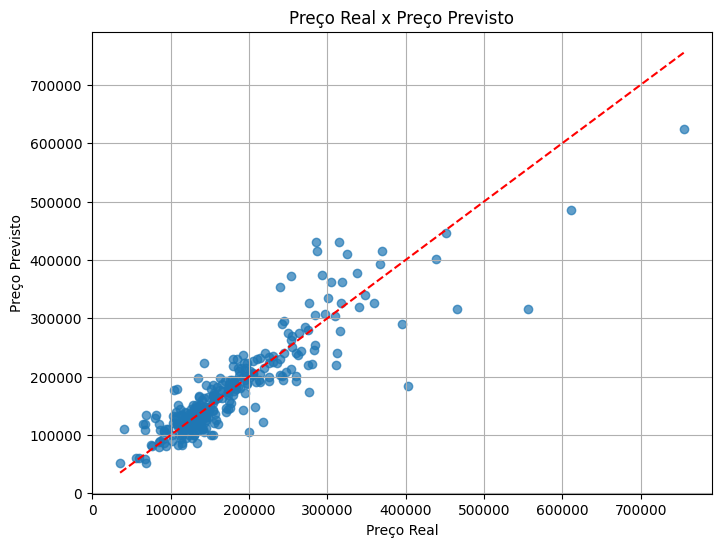

In [ ]:
# Decision Tree Regressor:
# Escolhi esse modelo pois percebi que algumas relações
# entre e o preço e as variáveis não são lineares, sendo
# assim a regressão linear não é tão útil. No decision
# tree regressor, o modelo é construído por meio de perguntas.

from sklearn.tree import DecisionTreeRegressor

# escolhendo as variáveis:
X = treino.drop(columns=["SalePrice"])
y = treino["SalePrice"]

# Separando treino e teste
X_train, X_test, y_train, y_test = separacao_dados(X, y)

# Criando o modelo
arvore = DecisionTreeRegressor(random_state=42)

# Treinando
arvore = treinamento(arvore, X_train, y_train)

# Fazendo previsões
y_pred_arvore = previsoes(arvore, X_test)

# Comparando resultados
resultado = comparando_resultados(X_test, y_test, y_pred_arvore)
print(resultado)

# Métricas
mae, mse, rmse, r2 = calculando_metricas(y_test, y_pred_arvore)

grafico_previsoes(y_test, y_pred_arvore)



In [ ]:
# Verificando se houve overfitting no modelo
print(arvore.score(X_train, y_train))
print(arvore.score(X_test, y_test))

1.0
0.7827939150592553


No gráfico Preço Real x Preço Previsto, observa-se uma maior dispersão dos pontos em relação à linha ideal, o que mostra que a Árvore de Decisão errou mais do que a Regressão Linear, principalmente para casas mais caras. O modelo apresentou um MAE próximo de 26 mil, ou seja, em média, o erro na previsão do preço das casas foi esse valor.

O RMSE foi 40.817,17, mostrando que algumas casas tiveram erros maiores. O R² foi de 0,78, mostrando que o modelo conseguiu explicar 78% da variação dos preços das casas. Esse resultado foi um pouco menor ao observado na Regressão Linear.

Ao comparar o desempenho da Árvore de Decisão nos conjuntos de treino e teste, observei um R² igual a 1,00 no treino e 0,78 no teste, o que prova que ocorreu overfitting. Isso significa que o modelo "decorou" os dados de treinamento, mas não conseguiu prever tão bem em dados novos de teste.

        Id  MSSubClass  LotFrontage  LotArea  OverallQual  OverallCond  \
892    893          20         70.0     8414            6            8   
1105  1106          60         98.0    12256            8            5   
413    414          30         56.0     8960            5            6   
522    523          50         50.0     5000            6            7   
1036  1037          20         89.0    12898            9            5   
...    ...         ...          ...      ...          ...          ...   
479    480          30         50.0     5925            4            7   
1361  1362          20        124.0    16158            7            5   
802    803          60         63.0     8199            7            5   
651    652          70         60.0     9084            4            5   
722    723          20         70.0     8120            4            7   

      YearBuilt  YearRemodAdd  MasVnrArea  BsmtFinSF1  ...  \
892        1963          2003         0.0        

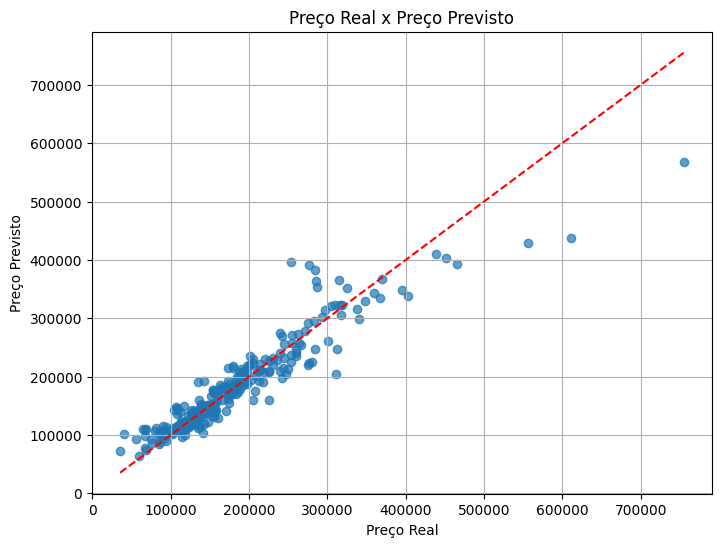

In [ ]:
# Random Forest:
# Escolhi pois é um ótimo modelo para prever relações
# complexas entre as variáveis e utiliza várias árvores
# de decisão, para diminuir o overfitting (presente no
# modelo anterior)

from sklearn.ensemble import RandomForestRegressor

# escolhendo as variáveis:
X = treino.drop(columns=["SalePrice"])
y = treino["SalePrice"]

# Separando treino e teste
X_train, X_test, y_train, y_test = separacao_dados(X, y)

# Criando o modelo
floresta = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Treinando
floresta = treinamento(floresta, X_train, y_train)

# Fazendo previsões
y_pred_floresta = previsoes(floresta, X_test)

# Comparando resultados
resultado = comparando_resultados(X_test, y_test, y_pred_floresta)
print(resultado)

# Métricas
mae, mse, rmse, r2 = calculando_metricas(y_test, y_pred_floresta)

# grafico valor previsto x valor real
grafico_previsoes(y_test, y_pred_floresta)





O modelo apresentou o melhor desempenho entre todos os modelos. No gráfico de Preço Real x Preço Previsto, observa-se que a maior parte das previsões ficou muito próximo do valor real, indicando uma boa capacidade de estimar os preços das casas.

O MAE(Erro Médio) foi de aproximadamente 18 mil. O RMSE foi de 30.309, o menor entre os modelos, o que indica que a Random Forest conseguiu diminuir muito os erros de previsão das casas mais caras. O R² foi de 0,88, mostrando que o modelo conseguiu explicar aproximadamente 88% da variação dos preços das casas. Esse desempenho muito melhor que os outros pode ter ocorrido porque há a combinação de diversas Árvores de Decisão, reduzindo o problema de overfitting observado no modelo anterior.

**Comparação entre os modelos**

| Modelo           |        MAE |       RMSE |       R² |
| ---------------- | ---------: | ---------: | -------: |
| Regressão Linear 1|     23.942 |      83.016|    0,10
| Regressão Linear 2|     23.513 |     38.747 |     0,80 |
| Decision Tree    |     25.983 |     40.817 |     0,78 |
| Random Forest    | 18.060 | 30.309 | 0,88 |

A Random Forest apresentou o melhor desempenho entre os modelos, atingindo um R² de 0,88, o que indica que conseguiu explicar cerca de 88% da variação dos preços das casas. Em seguida, a Regressão Linear 2 (após a seleção de variáveis) apresentou um bom desempenho, com um R² de 0,80.

O algoritmo com o penúltimo desempenho foi a Decision Tree, que teve um R² de 0,78, inferior aos demais. Ao analisar o desempenho de perto, percebi que este modelo sofreu overfitting.

Por fim, o pior resultado entre todos foi o da Regressão Linear 1, treinada com todas as variáveis brutas. Este modelo apresentou um RMSE extremamente elevado, mostrando que, quando o modelo erra, os desvios são extremamentes distantes do valor real, e apresentou um R² de  0,10. Essa grande diferença entre o primeiro e o segundo modelo de regressão demonstra o quanto a Engenharia de Atributos é importante para evitar redundância e melhorar a previsão dos modelos.

In [ ]:

# Variáveis mais importantes:

importancia = pd.DataFrame({
    "Variável": X.columns,
    "Importância": floresta.feature_importances_
})

# Remover apenas do gráfico, variáveis que já apareceram
# na engenharia de atributos.
remover = [
    "YrSold",
    "YearBuilt",
    "YearRemodAdd",
    "1stFlrSF",
    "2ndFlrSF",
    "TotalBsmtSF",
    "BsmtFinSF1",
    "BsmtFinSF2",
    "BsmtUnfSF",
    "GrLivArea",
    "WoodDeckSF",
    "OpenPorchSF",
    "EnclosedPorch",
    "3SsnPorch",
    "ScreenPorch",
    "FullBath",
    "HalfBath",
    "BsmtFullBath",
    "BsmtHalfBath"
]

importancias_grafico = importancia[
    ~importancia["Variável"].isin(remover)
]

importancias_grafico = importancias_grafico.sort_values( # variaveis mais
# importantes em ordem decrescente
    by="Importância",
    ascending=False
)

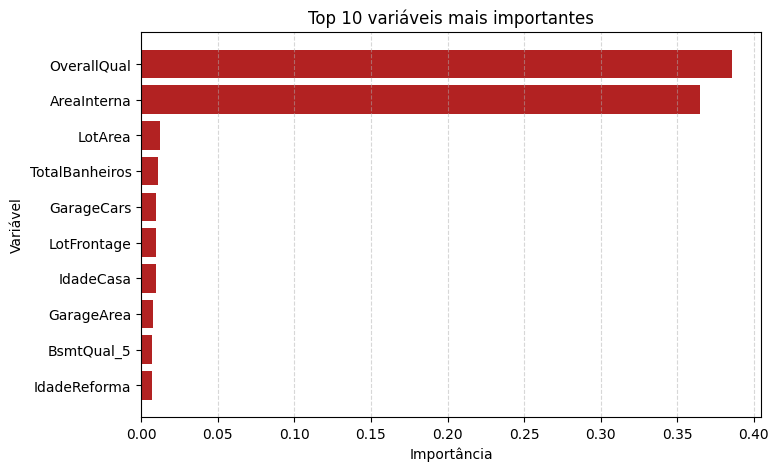

In [ ]:
import matplotlib.pyplot as plt

# Gráfico com as 10 variáveis mais importantes
top10 = importancias_grafico.head(10)

plt.figure(figsize=(8,5))

plt.barh(
    top10["Variável"],
    top10["Importância"],
    color="firebrick"
)

plt.gca().invert_yaxis()

plt.title("Top 10 variáveis mais importantes")
plt.xlabel("Importância")
plt.ylabel("Variável")

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.show()

O gráfico mostra que as variáveis mais importantes para prever o valor da variável 'SalePrice' foram OverallQual (qualidade geral da casa) e AreaInterna. Além disso, variáveis criadas durante a etapa de engenharia de atributos, como TotalBanheiros, IdadeCasa e IdadeReforma, também aparecem. Esse resultado mostra que a engenharia de features ajudou bastante o modelo, criando atributos mais representativos para a correta previsão dos valores.

8º Aprendizado Não Supervisionado

Usei o algoritmo K-Means para agrupar casas semelhantes em clusters. Diferente do Supervisionado que prevê os preços, nesse novo tipo de aprendizado, o objetivo é encontrar padrões e encontrar novos grupos sem usar a variável alvo 'SalePrice'.

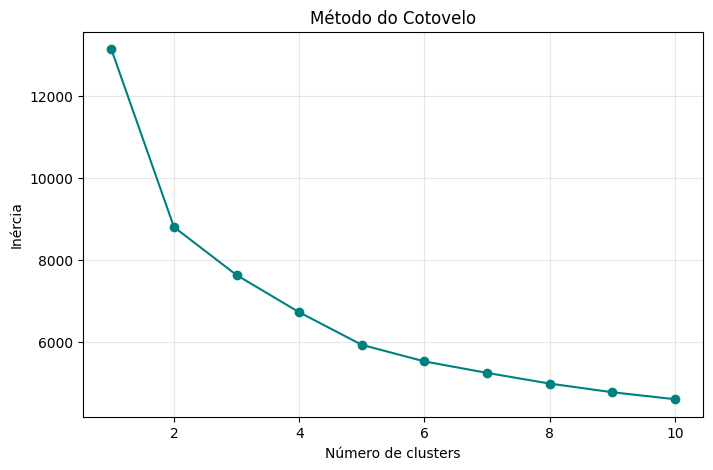

,OverallQual,AreaInterna,LotArea,TotalBanheiros,GarageCars,LotFrontage,GarageArea,IdadeCasa,IdadeReforma
Cluster,,,,,,,,,
0,8.004329,3751.679654,16704.307359,2.952381,2.727273,90.090909,764.082251,12.038961,6.497835
1,6.380952,2614.915873,9876.300000,2.530159,2.004762,67.477778,516.533333,21.214286,14.528571
2,5.068447,2059.859766,8804.348915,1.588481,1.146912,64.572621,314.911519,62.126878,38.151920


In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Para o treinamento utilizei as variáveis numéricas
# mais importantes identificadas anteriormente pela Random Forest.
# Essas variáveis representam características importantes relacionadas
# às residências, como tamanho, qualidade e idade dos imóveis.
X_cluster = treino[
    [
        "OverallQual",
        "AreaInterna",
        "LotArea",
        "TotalBanheiros",
        "GarageCars",
        "LotFrontage",
        "IdadeCasa",
        "GarageArea",
        "IdadeReforma"
    ]
]

# Padronização das variáveis, pois as variáveis possuem escalas
# diferentes entre si, como: área em m², quantidade de banheiro,
# idade em anos, etc. Assim, é evitado que variáveis com valores
# maiores influenciem demais a formação dos clusters.
scaler = StandardScaler()
X_cluster = scaler.fit_transform(X_cluster)


# Antes de treinar esse modelo, foi necessário definir a quantidade de
# clusters. Para fazer isso, usei o Método do Cotovelo, observando em
# qual ponto a redução da inércia deixava de ser significativa.
inercia = []
for k in range(1,11):
    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    modelo.fit(X_cluster)
    inercia.append(modelo.inertia_)


# Gráfico do método do cotovelo
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    inercia,
    marker="o",
    color="teal"
)

plt.title("Método do Cotovelo")
plt.xlabel("Número de clusters")
plt.ylabel("Inércia")
plt.grid(alpha=0.3)
plt.show()
# O gráfico indica que a maior redução ocorre próximo dos
# 3 clusters. Assim, usei esse valor no treinamento.


# Treinando o modelo
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_cluster)

# Adicionando ao dataframe
treino["Cluster"] = clusters

# Representação dos clusters
treino.groupby("Cluster")[
    [
        "OverallQual",
        "AreaInterna",
        "LotArea",
        "TotalBanheiros",
        "GarageCars",
        "LotFrontage",
        "GarageArea",
        "IdadeCasa",
        "IdadeReforma"
    ]
].mean()



O modelo conseguiu separar 3 clusters diferentes:
O algoritmo K-Means conseguiu separar os imóveis em três grupos com características distintas.

• Cluster 0: reúne casas de alta qualidade, possuindo, em média, maior qualidade de construção (OverallQual próximo de 8), maior área interna (≈ 3752), frente do terreno mais ampla (LotFrontage ≈ 90), lotes maiores (≈ 16.704), aproximadamente 3 banheiros, garagem para quase 3 veículos, maior área de garagem (764 metros)  e casas mais novas, com idade média de 12 anos e recentemente reformadas, com reforma média de 6 anos.

• Cluster 1: representa imóveis com uma qualidade intermediária, com qualidade de construção média de 6, área interna de cerca de 2615, frente do terreno menor(LotFrontage ≈67), com lotes bem menores que primeiro grupo (≈ 10.000), cerca de 2 banheiros, garagem para 2 veículos, idade média de 21 anos e tempo médio de reforma de 14 anos.

• Cluster 2: contém casas mais simples, com menor qualidade construtiva (≈ 5), menor área interna (≈ 2060), lotes menores (8800), aproximadamente 1,5 banheiros, garagem para apenas 1 veículo e idade média de 62 anos, além de reformas mais antigas (38 anos desde a última reforma).

Assim, é possível observar que o K-Means conseguiu diferenciar os tipos de casa em 3 grupos, seguindo uma ordem bem definida: casas mais caras vão possuir maior qualidade de construção, lotes maiores, maior área interna, mais banheiros, garagem que cabe mais carros, idade média mais nova e com reformas mais recentes.

**Conclusão Final**

1.   Sim, pelas análises feitas nesse projeto, constatei que casas com mais área interna, em média, vão ter um maior valor, principalmente para imóveis com até aproximadamente 4.500 pés² de área interna.
2.   Sim, a variável relacionada à qualidade geral do imóvel é a mais importante, apresentando uma relação positiva com o preço de venda, ou seja, quanto melhor a qualidade da casa maior vai ser o custo.
3. Sim, casas mais novas vão custar mais que casas antigas, porém a relação não é tão direta quanto a condição geral da casa. Existem casas mais velhas que custam mais que as novas, então essa variável não é tão importante para análise.
4. Sim, casas que foram recentemente reformadas custam, em média, mais caro que as casas que não foram. Essa relação é muito apresentada pela variável 'IdadeReforma'.
5. Sim, existe uma relação positiva entre o número de banheiros e o preço dos imóveis, principalmente com aproximadamente quatro banheiros. Acima disso, essa tendência deixa de ser tão evidente, pode ser motivado pela pequena quantidade de imóveis com essa característica.
6. O bairro da residência influencia o valor do imóvel. O bairro mais caro é 'NoRidge" custando 330 mil em média, enquanto o mais barato 'Meadow' custa 98 mil. Porém, nesse modelo a vizinhança não foi um dos fatores que mais influenciaram, outro como OverallCond e AreaInterna foram mais importantes.
7. Para o modelo Random Forest, as variáveis mais importantes foram:
*   OverallQual: Qualidade geral do imóvel.
* AreaInterna: Área interna total.
* LotArea: Área total do terreno.
* TotalBanheiros: Quantidade total de banheiros.
* GarageCars: Número de veículos que cabem na garagem.
* LotFrontage: Largura da frente do terreno.
* IdadeCasa: Idade da residência.
* GarageArea: Área da garagem.
* BsmtQual_5: Qualidade do porão classificada no nível mais alto após o one-hot-encoding.
* IdadeReforma: Tempo desde a última reforma da casa.
8. Nesse dataset, o melhor modelo supervisionado entre os avaliados foi o Random Forest, com um MAE(Erro Médio) de aproximadamente 18 mil, ou seja, em média errou 18 mil nos preços da casa e atingiu um R² de 0,88, o que indica que o modelo conseguiu explicar aproximadamente 88% da variação dos preços das casas.
9. Sim. A utilização de todas as variáveis alterou o desempenho da Regressão Linear. Neste projeto, a seleção das variáveis mais relevantes teve melhores resultados do que usar todas as variáveis disponíveis. Isso pode ter ocorrido porque nem todas as variáveis são úteis para prever os preços das casas e também muitas variáveis carregam informações redundantes, o que acaba prejudicando o modelo.
10. Sim. A engenharia de features foi muito importante no projeto, pois permitiu criar novas variáveis que foram capazes de representar melhor algumas características dos imóveis. Como, por exemplo: AreaInterna, TotalBanheiros, IdadeCasa e IdadeReforma. Essas variáveis contribuíram para melhorar o desempenho dos modelos, já que quatro delas apareceram entre as dez variáveis mais importantes identificadas pela Random Forest.
11. Sim. O algoritmo K-Means conseguiu separar três grupos distintos de imóveis usando apenas suas características, sem considerar o preço de venda. Os clusters encontrados representam, de maneira geral:
* Cluster 0: imóveis de alto padrão, com maior qualidade de construção, maior área interna, terrenos maiores, mais banheiros, garagens maiores e construções mais recentes.
* Cluster 1: imóveis de padrão intermediário, com características medianas em relação à área, qualidade e idade.
* Cluster 2: imóveis de padrão mais simples, com menor área, menor qualidade, menos banheiros, garagens menores e maior idade.



**Conclusão Geral**

O desenvolvimento deste projeto me ajudou a entender, na prática, quais características das residências exercem maior influência sobre o preço dos imóveis e comparar diferentes modelos de Machine Learning. Entre os modelos supervisionados avaliados, a Random Forest apresentou o melhor desempenho, enquanto o K-Means, modelo de aprendizado não supervisionado, mostrou ser capaz de identificar perfis bastante diferentes de residências usando apenas suas características. Por fim, a engenharia de features foi uma etapa muito importante, ajudando a melhorar o desempenho dos modelos.
